In [58]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

### Now We Load The Dataset

In [59]:
df = pd.read_csv("../dataset/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

The datasets are loaded perfectly. 

In [61]:
y = df["Target"]
print(y.value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


There are 3 classes, so our Logistic Regression will perform multiclass classification.

# Separating features and target

In [62]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4424, 36)
Target shape: (4424,)


# Spliting the dataset

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3539, 36)
Testing data: (885, 36)


# Features Scaling and training

In [64]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


# prediction generating 

In [65]:
y_pred = model.predict(X_test_scaled)
print("Predictions generated successfully.")

Predictions generated successfully.


# Calculate Accuracy

In [66]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.7684
Logistic Regression Accuracy: 76.84%


# Classification Report

In [67]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



# Confusion Matrix

In [68]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[218  29  37]
 [ 43  53  63]
 [ 14  19 409]]


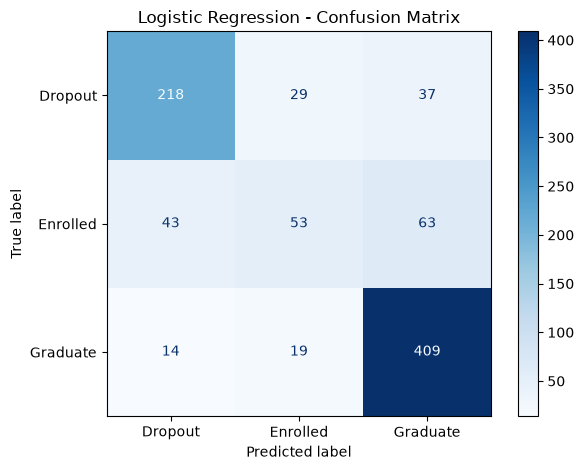

In [69]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../results/logistic regression/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Logistic Regression model achieved an accuracy of **76.84%** on the test dataset. The model performed best in predicting the **Graduate** class, with a precision of **0.80**, recall of **0.93**, and F1-score of **0.86**. The **Dropout** class also showed good performance, with an F1-score of **0.78**.

However, the model had difficulty identifying the **Enrolled** class, achieving a recall of only **0.33** and an F1-score of **0.41**. The confusion matrix shows that several Enrolled students were incorrectly classified as either Dropout or Graduate.

Overall, the Logistic Regression model provided reasonable performance for predicting student outcomes, but its ability to correctly identify the Enrolled class was relatively weak.